In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
from solver_new import *

# 1D Tests in periodic conditions

## Stationnary equation
### With psiOp()

In [ ]:
# Define symbolic variables
x, xi = symbols('x xi')
u = Function('u')(x)

# Define the PDE: psiOp[xi^2 + 1, u](x) = 0
equation = Eq(psiOp(xi**2 + 1, u), sin(x))  # rhs will be overwritten

# Define exact solution

def u_exact(x):
    return np.sin(x)/2

# Create the solver
solver = PDESolver(equation)

# Setup parameters
Lx = 2 * np.pi
Nx = 256
solver.setup(Lx=Lx, Nx=Nx, initial_condition=None)

# Solve the stationary problem
u_num = solver.solve_stationary_psiOp(order=1)

# Exact solution on grid
u_ref = u_exact(solver.X)

# Compute relative L2 error
error = np.linalg.norm(np.real(u_num) - u_ref) / np.linalg.norm(u_ref)

solver.test(u_exact=u_exact, threshold=5e-3, component='abs')

solver.show_stationary_solution(u=u_num, component='real')

### With psiOp() depending on $x$

In [ ]:
# Define symbolic variables
x, xi = symbols('x xi', real=True)
u = Function('u')(x)

# Define the symbol
p_symbol = xi**2 + x**2 + 1

# Define the right-hand side f(x) = P[u_exact]
f_expr = 3 * (1 - x**2) * exp(-x**2)

# Define the full equation: P[u] = f
equation = Eq(psiOp(p_symbol, u), f_expr)

# Exact and initial
def u_exact(x): return np.exp(-x**2)


solver = PDESolver(equation)
solver.setup(Lx=30, Nx=1024, initial_condition=None)

u_num = solver.solve_stationary_psiOp(order=1)
solver.test(u_exact=u_exact, threshold=2, component='real')


## Integro-differential equation
### With Op

In [ ]:
# Define the symbols and the integro-differential equation
t, x, kx, xi, omega = symbols('t x kx xi omega')
u_func = Function('u')
u = u_func(t, x)
eps = 0.001
# Define the equation with an integral term using Op
integral_term = Op(1 / (I * (kx + eps)), u)

eq = Eq(diff(u, t), diff(u, x) + integral_term - u)

# Create the solver
# solver = PDESolver(eq, time_scheme='ETD-RK4', dealiasing_ratio=2/3)
solver = PDESolver(eq, time_scheme='ETD-RK4')

# Simulation parameters
Lt = 2.0  # Total simulation time
Lx = 20   # Spatial domain size
Nx = 1024 # Number of grid points
Nt = 200  # Number of time steps

# Initial condition
initial_condition = lambda x: np.sin(x)

# Setup the solver
solver.setup(
    Lx=Lx, Nx=Nx, Lt=Lt, Nt=Nt,
    initial_condition=initial_condition
)

# Solve the equation
solver.solve()

# Exact solution at any time t
def u_exact(x, t):
    return np.exp(-t) * np.sin(x)

# Automatic testing at multiple times
n_test = 4
test_set = [
    solver.test(
        u_exact=u_exact,
        t_eval=i * Lt / n_test,
        threshold=0.5,  # Adjust threshold if necessary
        component='real'
    )
    for i in range(n_test + 1)
]


### With psiOp


*********************************
* Partial differential equation *
*********************************

∂                  ⎛              ⅈ             ⎞
──(u(t, x)) = psiOp⎜ⅈ⋅ξ - 1 - ─────────, u(t, x)⎟
∂t                 ⎝          ξ + 0.001         ⎠

********************
* Equation parsing *
********************


Equation rewritten in standard form: -psiOp(I*xi - 1 - I/(xi + 0.001), u(t, x)) + Derivative(u(t, x), t)
⚠️ psiOp detected: skipping expansion for safety

Expanded equation: -psiOp(I*xi - 1 - I/(xi + 0.001), u(t, x)) + Derivative(u(t, x), t)
Analyzing term: -psiOp(I*xi - 1 - I/(xi + 0.001), u(t, x))
  --> Classified as pseudo linear term (psiOp)
Analyzing term: Derivative(u(t, x), t)
  Derivative found: Derivative(u(t, x), t)
  --> Classified as linear
Final linear terms: {Derivative(u(t, x), t): 1}
Final nonlinear terms: []
Symbol terms: []
Pseudo terms: [(-1, I*xi - 1 - I/(xi + 0.001))]
Source terms: []
⚠️  Pseudo‑differential operator detected: all other linear terms h

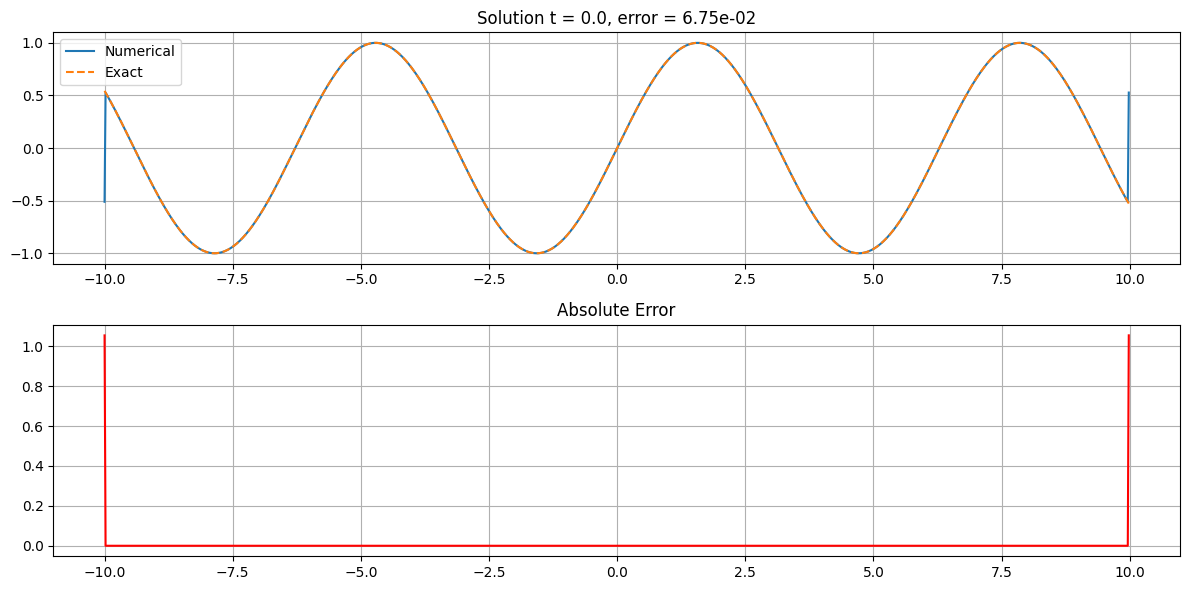

Closest available time to t_eval=0.5: 0.5
Test error t = 0.5: 2.442e-01


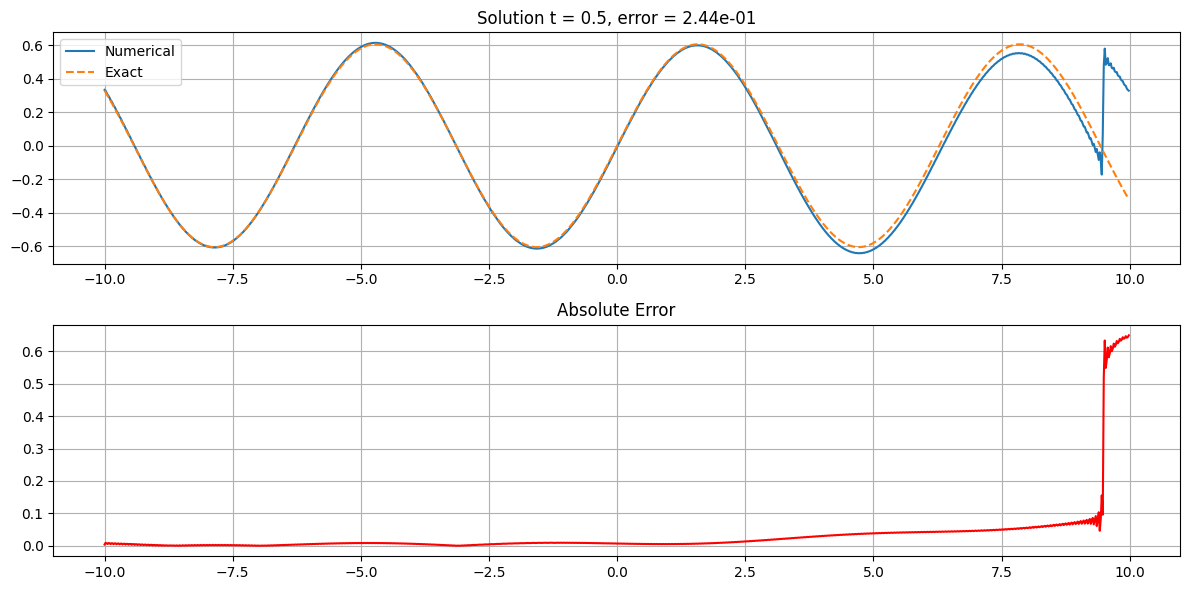

Closest available time to t_eval=1.0: 1.0
Test error t = 1.0: 3.444e-01


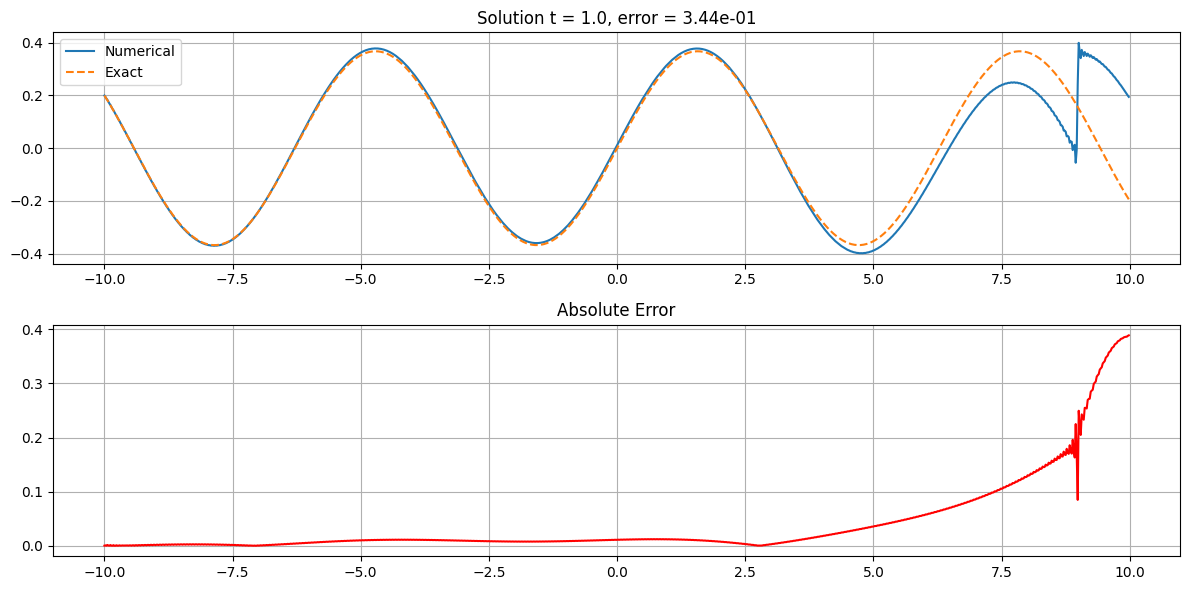

Closest available time to t_eval=1.5: 1.5
Test error t = 1.5: 4.190e-01


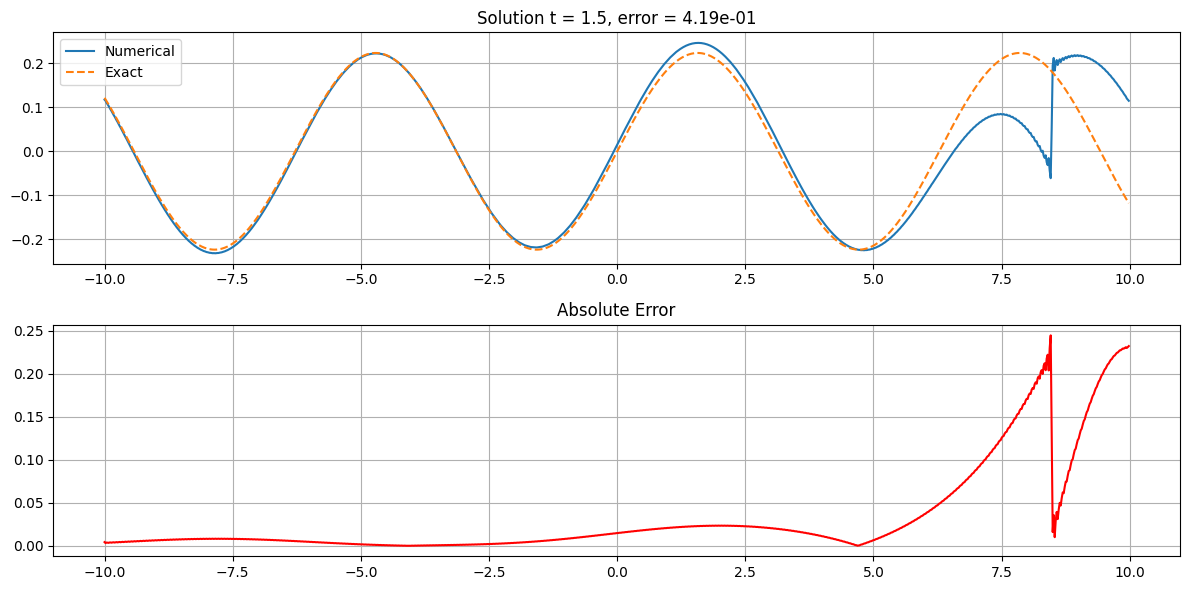

Closest available time to t_eval=2.0: 2.0
Test error t = 2.0: 4.824e-01


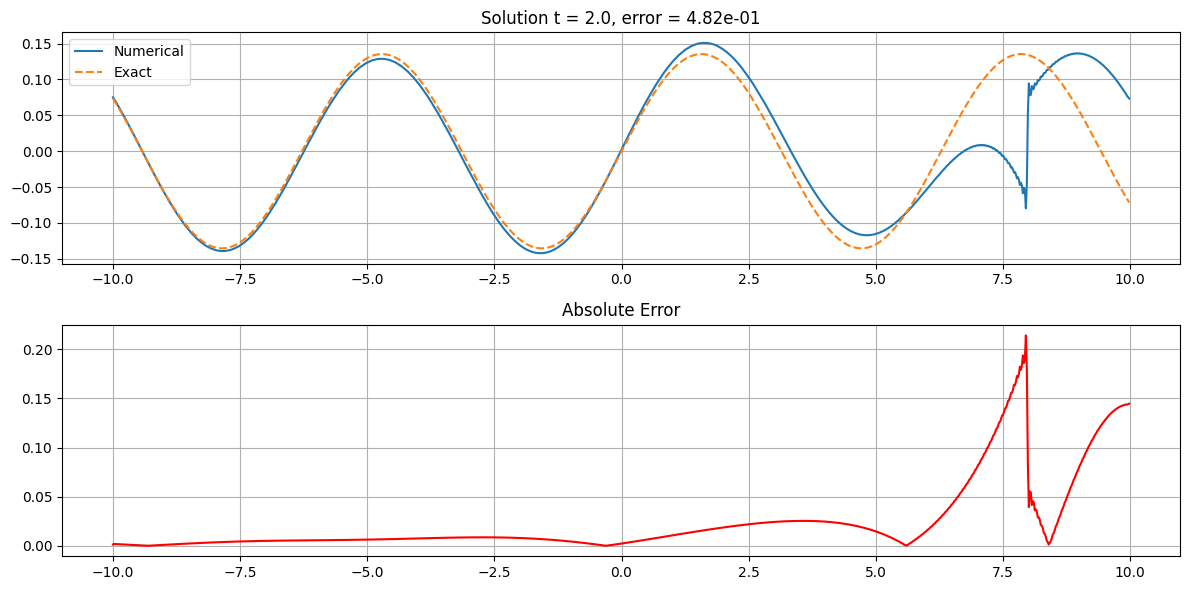

In [7]:
# Define the symbols and the integro-differential equation
t, x, xi, omega = symbols('t x xi omega')
u_func = Function('u')
u = u_func(t, x)
eps = 0.001
# Define the equation with an integro-differential term using psiOp
integral_term = psiOp(I*xi + 1 / (I * (xi + eps)) - 1, u)

eq = Eq(diff(u, t), integral_term)

# Create the solver
# solver = PDESolver(eq, time_scheme='ETD-RK4', dealiasing_ratio=2/3)
solver = PDESolver(eq, dealiasing_ratio=2/3)

# Simulation parameters
Lt = 2.0  # Total simulation time
Lx = 20   # Spatial domain size
Nx = 1024 # Number of grid points
Nt = 200  # Number of time steps

# Initial condition
initial_condition = lambda x: np.sin(x)

# Setup the solver
solver.setup(
    Lx=Lx, Nx=Nx, Lt=Lt, Nt=Nt,
    initial_condition=initial_condition
)

# Solve the equation
solver.solve()

# Exact solution at any time t
def u_exact(x, t):
    return np.exp(-t) * np.sin(x)

# Automatic testing at multiple times
n_test = 4
test_set = [
    solver.test(
        u_exact=u_exact,
        t_eval=i * Lt / n_test,
        threshold=0.5,  # Adjust threshold if necessary
        component='real'
    )
    for i in range(n_test + 1)
]


## Convolution equation
### With Op

In [ ]:
# Define symbols
t, x, kx, xi, omega, lam = symbols('t x kx xi omega lambda')
u_func = Function('u')
u = u_func(t, x)
lam = 1.0
# Define the kernel f(x) = exp(-lambda * |x|)
f_kernel = exp(-lam * Abs(x))

# Convolution equation: ∂t u = - OpConv(f_kernel, u)
eq = Eq(diff(u, t), -Op(fourier_transform(f_kernel, x, kx/(2*pi)), u))

# Create solver with lambda=1
solver = PDESolver(eq.subs(lam, 1), time_scheme='ETD-RK4')

# Simulation parameters
Lt = 2.0
solver.setup(
    Lx=2 * np.pi, Nx=256, Lt=Lt, Nt=100,
    initial_condition=lambda x: np.cos(x)
)

# Solve
solver.solve()

# Exact solution: u(x, t) = cos(x) * exp(- (2*lambda / (lambda^2 + k^2)) * t )
def u_exact(x, t):
    lam_val = 1.0
    k_val = 1.0  # mode k=1 (cos(x))
    decay = 2 * lam_val / (lam_val**2 + k_val**2)
    return np.cos(x) * np.exp(-decay * t)

# Automatic testing at multiple times
n_test = 4
test_set = [solver.test(u_exact=u_exact, t_eval=i * Lt / n_test, threshold=5e-3, component='abs')
            for i in range(n_test + 1)]


### With psiOp

In [ ]:
# Define symbols
t, x, kx, xi, omega, lam = symbols('t x kx xi omega lambda')
u_func = Function('u')
u = u_func(t, x)
lam = 1.0
# Define the kernel f(x) = exp(-lambda * |x|)
f_kernel = exp(-lam * Abs(x))

# Convolution equation: ∂t u = - OpConv(f_kernel, u)
eq = Eq(diff(u, t), -psiOp(fourier_transform(f_kernel, x, xi/(2*pi)), u))

# Create solver with lambda=1
solver = PDESolver(eq.subs(lam, 1))

# Simulation parameters
Lt = 2.0
solver.setup(
    Lx=2 * np.pi, Nx=256, Lt=Lt, Nt=100,
    initial_condition=lambda x: np.cos(x)
)

# Solve
solver.solve()

# Exact solution: u(x, t) = cos(x) * exp(- (2*lambda / (lambda^2 + k^2)) * t )
def u_exact(x, t):
    lam_val = 1.0
    k_val = 1.0  # mode k=1 (cos(x))
    decay = 2 * lam_val / (lam_val**2 + k_val**2)
    return np.cos(x) * np.exp(-decay * t)

# Automatic testing at multiple times
n_test = 4
test_set = [solver.test(u_exact=u_exact, t_eval=i * Lt / n_test, threshold=5e-3, component='abs')
            for i in range(n_test + 1)]


## Transport equation
### With PDE

In [ ]:
# Define the symbols and the 1D transport equation
t, x, kx, xi, omega = symbols('t x kx xi omega')
u_func = Function('u') 
u = u_func(t, x)

eq = Eq(diff(u, t), -diff(u, x))  # Rightward transport at speed +1

# Create the solver
solver = PDESolver(eq, time_scheme='ETD-RK4')
Lt=5.0
# Domain setup and initial condition
solver.setup(
    Lx=10, Nx=256, Lt=Lt, Nt=2000,
    initial_condition=lambda x: np.exp(-x**2)
)

# Solving
solver.solve()

# Exact solution at t = 2.0 (with periodic wrapping)
def u_exact(x, t):
    L = 10  # Domain length
    return np.exp(-((x - t + L/2) % L - L/2)**2)

# Automatic testing
n_test = 5
test_set = [solver.test(u_exact=u_exact, t_eval=i * Lt / n_test, threshold=5e-2, component='real') for i in range(n_test + 1)]

### With Op

In [ ]:
# Define symbols and equation
t, x, kx, xi, omega = symbols('t x kx xi omega')
u_func = Function('u')
u = u_func(t, x)

# Parameters
c = 1.0
beta = 1.3

# Equation
eq = Eq(diff(u, t) + c * diff(u, x), -Op(abs(kx)**beta, u))

# Create the solver
solver = PDESolver(eq, dealiasing_ratio=0.5, time_scheme='ETD-RK4')
Lt=2.0
# Domain and initial condition setup
solver.setup(
    Lx=2 * np.pi, Nx=256, Lt=Lt, Nt=2000,
    initial_condition=lambda x: np.cos(x)
)

# Solve the equation
solver.solve()

# Exact solution function at t = 1
def u_exact(x, t):
    return np.cos(x - c * t) * np.exp(-t * abs(1)**beta)

# Automatic testing
n_test = 4
test_set = [solver.test(u_exact=u_exact, t_eval=i * Lt / n_test, threshold=7e-2, component='real') for i in range(n_test + 1)]

### With psiOp

In [ ]:
# Define symbols and equation
t, x, kx, xi, omega = symbols('t x kx xi omega')
u_func = Function('u')
u = u_func(t, x)

# Parameters
c = 1.0
beta = 1.3

# Equation
eq = Eq(diff(u, t), -psiOp(c*I*xi + abs(xi)**beta, u))

# Create the solver
solver = PDESolver(eq, dealiasing_ratio=2/3)
Lt=2.0
# Domain and initial condition setup
solver.setup(
    Lx=2 * np.pi, Nx=256, Lt=Lt, Nt=2000,
    initial_condition=lambda x: np.cos(x)
)

# Solve the equation
solver.solve()

# Exact solution function at t = 1
def u_exact(x, t):
    return np.cos(x - c * t) * np.exp(-t * abs(1)**beta)

# Automatic testing
n_test = 4
test_set = [solver.test(u_exact=u_exact, t_eval=i * Lt / n_test, threshold=7e-2, component='real') for i in range(n_test + 1)]

## Heat equation
### with periodic initial condition

In [ ]:
# Define the symbols and the equation
t, x, kx, xi, omega = symbols('t x kx xi omega')
u_func = Function('u') 
u = u_func(t, x)

# 1D heat equation
eq = Eq(diff(u, t), diff(u, x, x)) 

# Create the solver
solver = PDESolver(eq, time_scheme='ETD-RK4')
Lt=2.0
# Domain and initial condition setup
solver.setup(
    Lx=2 * np.pi, Nx=256, Lt=Lt, Nt=100,
    initial_condition=lambda x: np.sin(x)
)

# Solve the equation
solver.solve()

# Exact solution function
def u_exact(x, t):
    return np.sin(x) * np.exp(-t)

# Automatic testing
n_test = 4
test_set = [solver.test(u_exact=u_exact, t_eval=i * Lt / n_test, threshold=5e-2, component='real') for i in range(n_test + 1)]


### with compact support initial condition


In [ ]:
# Definition of symbols and equation
t, x, kx, xi, omega = symbols('t x kx xi omega')
u = Function('u')(t, x)

# 1D heat equation
eq = Eq(diff(u, t), diff(u, x, x))

# Creation of the solver with ETD-RK4 scheme
solver = PDESolver(eq, time_scheme='ETD-RK4')

# Simulation parameters
Lt = 2.0  # Total time
Lx = 5 * np.pi  # Spatial domain
Nx = 256  # Grid points
Nt = 100  # Time steps

# Solver setup with Gaussian initial condition
solver.setup(
    Lx=Lx,
    Nx=Nx,
    Lt=Lt,
    Nt=Nt,
    initial_condition=lambda x: np.exp(-2 * x**2)  # Gaussian σ=0.5
)

# Solving the equation
solver.solve()

# Exact solution for the Gaussian with diffusion
def u_exact(x, t):
    sigma = 0.5
    variance = sigma**2 + 2 * t  # Variance increases linearly
    return (np.exp(-x**2 / (2 * variance)) /
            np.sqrt(1 + 2 * t / sigma**2))

# Automated tests at different times
n_test = 4
test_set = [
    solver.test(
        u_exact=u_exact,
        t_eval=i * Lt / n_test,
        threshold=5e-3,  
        component='real'
    )
    for i in range(n_test + 1)
]

# Animate the solution
ani = solver.animate()
HTML(ani.to_jshtml())

### With Op

In [ ]:
# Define the symbols and the equation
t, x, kx, xi, omega = symbols('t x kx xi omega')
u_func = Function('u') 
u = u_func(t, x)

# 1D heat equation
#eq = Eq(diff(u, t),  diff(u, x, 2)) 
eq = Eq(diff(u, t), Op((I*kx)**2, u)/2 + diff(u, x, 2)/2)
#eq = Eq(Op(-(I*omega),u), Op(-(I*kx)**2, u)/2 + diff(u, x, 2)/2)
# Create the solver
solver = PDESolver(eq, time_scheme='ETD-RK4')
Lt=2.0
# Domain and initial condition setup
solver.setup(
    Lx=2 * np.pi, Nx=256, Lt=2.0, Nt=100,
    initial_condition=lambda x: np.sin(x)
)

# Solve the equation
solver.solve()

# Exact solution function at t = 1
def u_exact(x, t):
    return np.sin(x) * np.exp(-t)

# Automatic testing
n_test = 4
test_set = [solver.test(u_exact=u_exact, t_eval=i * Lt / n_test, threshold=5e-2, component='real') for i in range(n_test + 1)]


### In full Op formulation

In [ ]:
# Define the symbols and the equation
t, x, kx, xi, omega = symbols('t x kx xi omega')
u_func = Function('u') 
u = u_func(t, x)

# 1D heat equation in Op formulation
# eq = Eq(Op((-I*omega), u), diff(u, x, x))
eq = Eq(Op((-I*omega), u), Op((-I*kx)**2, u))

# Create the solver
solver = PDESolver(eq, time_scheme='ETD-RK4')
Lt=2.0
# Domain and initial condition setup
solver.setup(
    Lx=2 * np.pi, Nx=512, Lt=Lt, Nt=400,
    initial_condition=lambda x: np.sin(x),
    initial_velocity=lambda x: np.zeros_like(x)  # ∂u/∂t(x,0) = 0
)

# Solve the equation
solver.solve()

# Exact solution function
def u_exact(x, t):
    return np.sin(x) * np.exp(-t)

# Automatic testing
n_test = 4
test_set = [solver.test(u_exact=u_exact, t_eval=i * Lt / n_test, threshold=2e-2, component='real') for i in range(n_test + 1)]

### With fractional Op

In [ ]:
# Define symbols and equation
t, x, kx, xi, omega = symbols('t x kx xi omega')
u_func = Function('u')
u = u_func(t, x)

# Parameters
alpha = 1.8
nu = 0.1

# Equation
eq = Eq(diff(u, t), -Op(abs(kx)**alpha, u) + nu * diff(u, x, 2))

# Create the solver
solver = PDESolver(eq, dealiasing_ratio=0.5, time_scheme='ETD-RK4')
Lt=2.0
# Domain and initial condition setup
solver.setup(
    Lx=2 * np.pi, Nx=256, Lt=Lt, Nt=2000,
    initial_condition=lambda x: np.sin(x)
)

# Solve the equation
solver.solve()

# Exact solution function at t = 1
def u_exact(x, t):
    return np.sin(x) * np.exp(-t * (abs(1)**alpha + nu * 1**2))

# Automatic testing
n_test = 4
test_set = [solver.test(u_exact=u_exact, t_eval=i * Lt / n_test, threshold=2e-2, component='real') for i in range(n_test + 1)]

## Diffusion equation
### With fractional Op

In [ ]:
# Define the symbols and the equation
t, x, kx, xi, omega = symbols('t x kx xi omega')
u_func = Function('u') 
u = u_func(t, x)

# Fractional diffusion equation with alpha = 1.5 and added dissipation
alpha = 1.5
nu = 0.01  # Diffusion coefficient
# eq = Eq(diff(u, t), Op(abs(kx)**alpha, u) + nu * diff(u, x, 2))
eq = Eq(diff(u, t), -Op(abs(kx)**alpha, u))

# Create the solver
solver = PDESolver(eq, dealiasing_ratio=0.5, time_scheme='ETD-RK4')
Lt=2.0
# Domain and initial condition setup
solver.setup(
    Lx=2 * np.pi, Nx=256, Lt=Lt, Nt=2000,  # Reduced dt by increasing Nt
    initial_condition=lambda x: np.sin(x)
)

# Solve the equation
solver.solve()

# Exact solution function at t = 1
def u_exact(x, t):
    return np.sin(x) * np.exp(-t * abs(1)**alpha)

# Automatic testing
n_test = 4
test_set = [solver.test(u_exact=u_exact, t_eval=i * Lt / n_test, threshold=5e-2, component='real') for i in range(n_test + 1)]

### With psiOp


*********************************
* Partial differential equation *
*********************************

∂                  ⎛  2         ⎞
──(u(t, x)) = psiOp⎝-ξ , u(t, x)⎠
∂t                               

********************
* Equation parsing *
********************


Equation rewritten in standard form: -psiOp(-xi**2, u(t, x)) + Derivative(u(t, x), t)
⚠️ psiOp detected: skipping expansion for safety

Expanded equation: -psiOp(-xi**2, u(t, x)) + Derivative(u(t, x), t)
Analyzing term: -psiOp(-xi**2, u(t, x))
  --> Classified as pseudo linear term (psiOp)
Analyzing term: Derivative(u(t, x), t)
  Derivative found: Derivative(u(t, x), t)
  --> Classified as linear
Final linear terms: {Derivative(u(t, x), t): 1}
Final nonlinear terms: []
Symbol terms: []
Pseudo terms: [(-1, -xi**2)]
Source terms: []
⚠️  Pseudo‑differential operator detected: all other linear terms have been rejected.

*******************************
* Linear operator computation *
*******************************


Charac

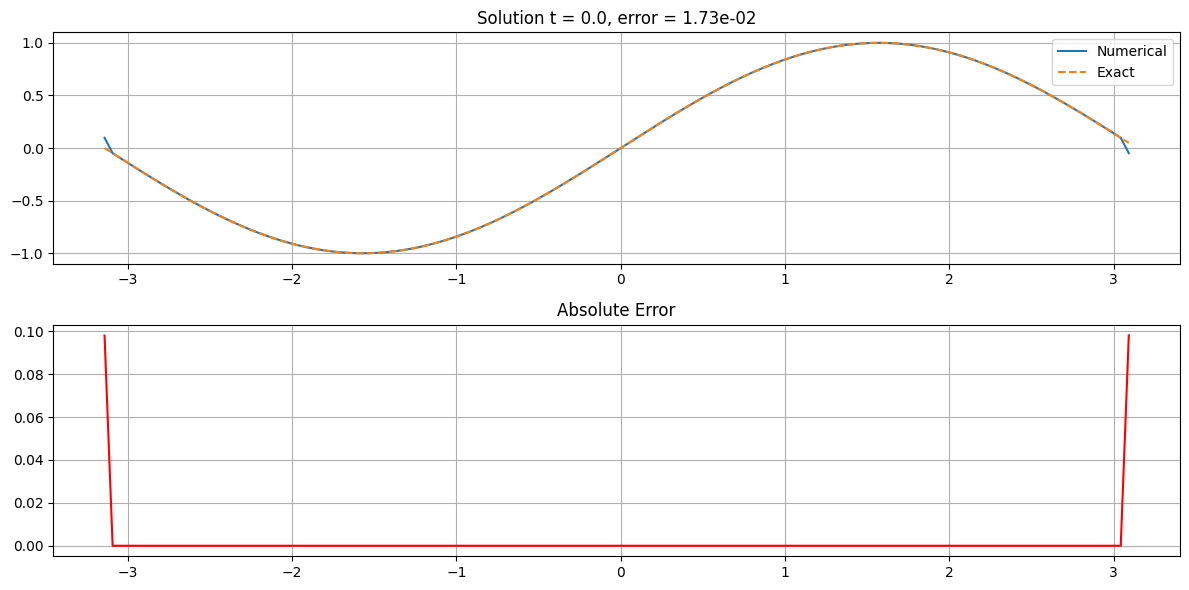

Closest available time to t_eval=0.5: 0.5
Test error t = 0.5: 1.852e-02


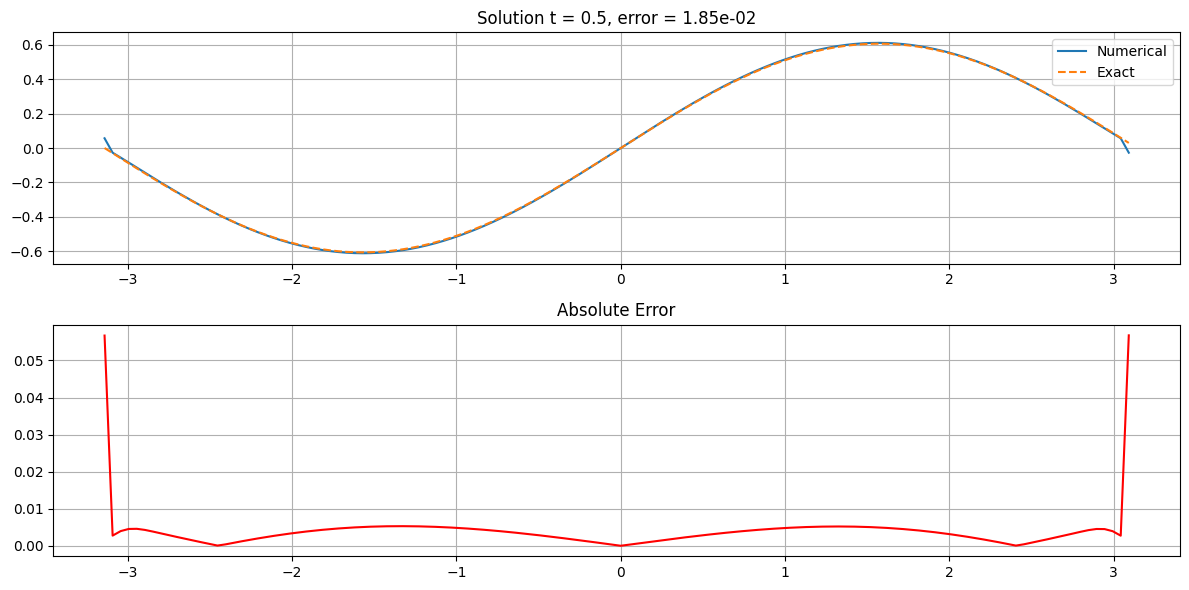

Closest available time to t_eval=1.0: 1.0
Test error t = 1.0: 1.771e-02


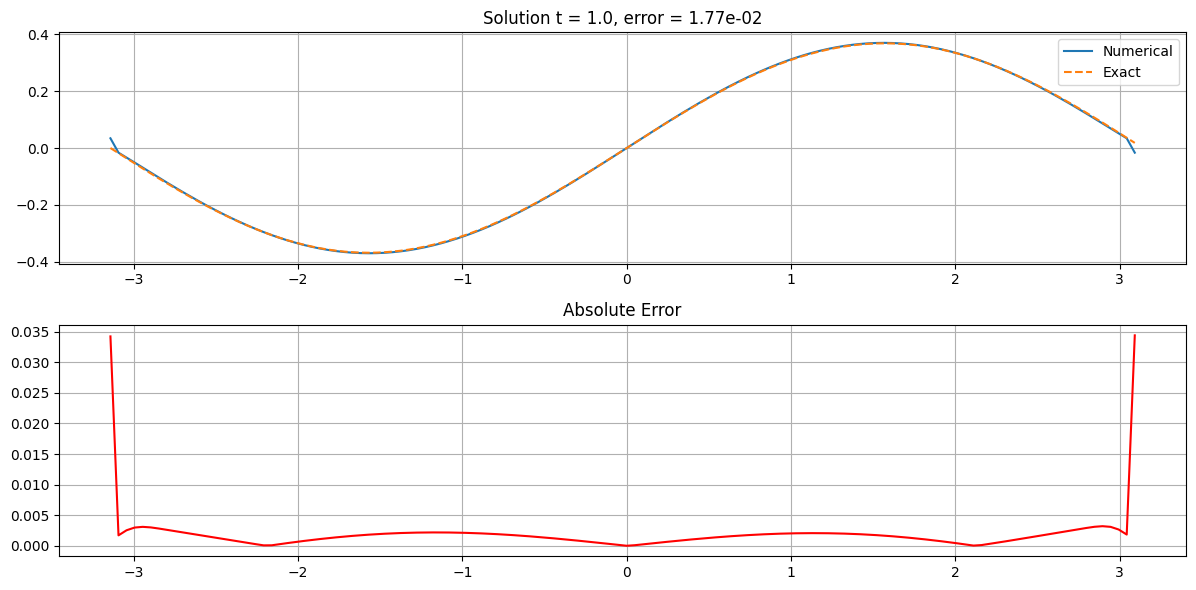

Closest available time to t_eval=1.5: 1.5
Test error t = 1.5: 1.745e-02


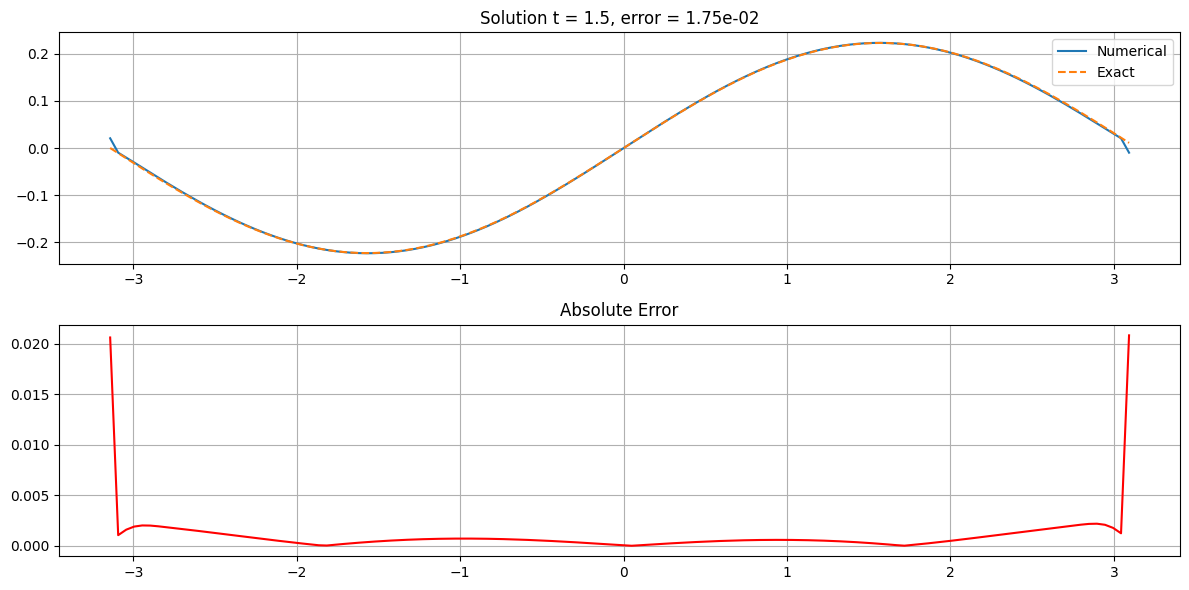

Closest available time to t_eval=2.0: 2.0
Test error t = 2.0: 1.786e-02


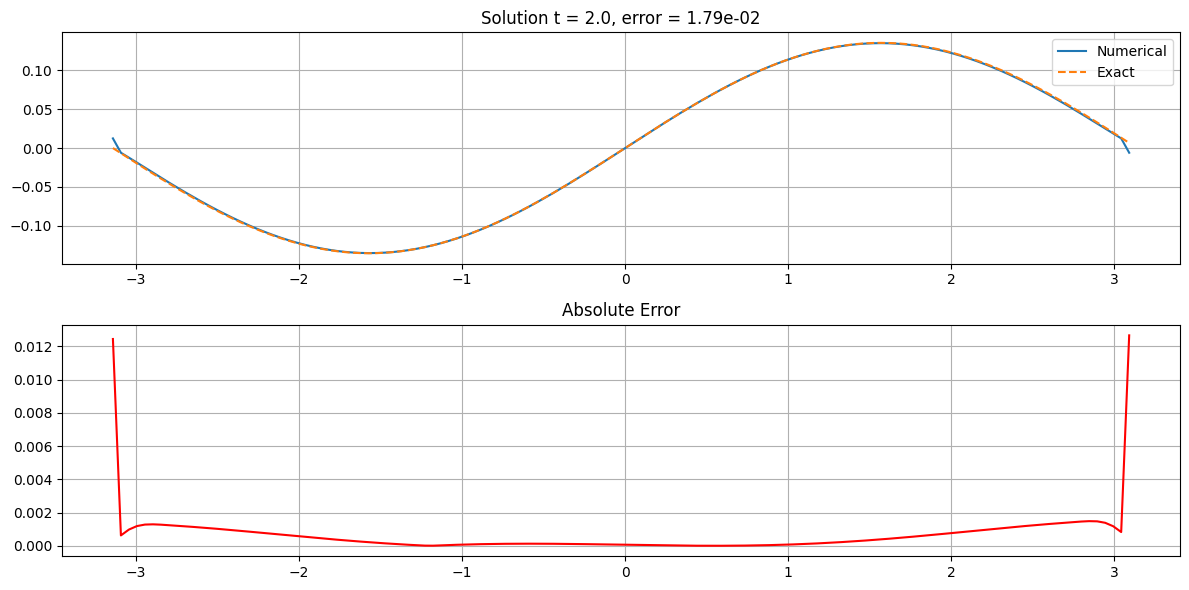

In [5]:
# Definition of the PDE: ∂u/∂t = - ∂²u/∂x² (diffusion equation)
u = Function('u')
t, x, xi = symbols('t x xi')
eq = Eq(diff(u(t,x), t), psiOp(-xi**2, u(t,x)))

# Solver configuration
solver = PDESolver(eq)
Lt=2.0
solver.setup(Lx=2*np.pi, Nx=128, Lt=Lt, Nt=200,
             initial_condition=lambda x: np.sin(x))

# Solving and visualization
solver.solve()

# Exact solution function
def u_exact(x, t):
    return np.sin(x) * np.exp(-t)

# Automatic testing
n_test = 4
test_set = [solver.test(u_exact=u_exact, t_eval=i * Lt / n_test, threshold=5e-2, component='real') for i in range(n_test + 1)]


## Burgers' equation

In [ ]:
# Definition of symbols and equation
t, x, kx, xi, omega = symbols('t x kx xi omega')
u = Function('u')(t, x)

# 1D Burgers equation
nu = 0.1
eq = Eq(diff(u, t), -u * diff(u, x) + nu * diff(u, x, x))

# Corrected exact solution
def phi(x, t):
    return 2 + np.sin(x) * np.exp(-nu * t)


def dphi_dx(x, t):
    return np.cos(x) * np.exp(-nu * t)

def u_exact(x, t):
    return -2 * nu * dphi_dx(x, t) / phi(x, t)

# Creation of the solver
solver = PDESolver(eq, time_scheme='ETD-RK4')
Lt = 1.0

# Configuration with corrected initial condition
solver.setup(
    Lx=2 * np.pi, Nx=256, Lt=Lt, Nt=200,
    initial_condition=lambda x: u_exact(x, 0)
)

# Solving
solver.solve()

# Automated tests
n_test = 4
test_set = [
    solver.test(
        u_exact=u_exact,
        t_eval=i * Lt / n_test,
        threshold=5e-2,  # Adjusted threshold
        component='real'
    )
    for i in range(n_test + 1)
]


## Equation with psiOp depending on spatial variable but not on $\xi$

In [ ]:
# === Symbols ===
t, x, xi = symbols('t x xi', real=True)
u = Function('u')
# === Symbol dependent on x, periodic
symbol_expr = 1 + sin(x)
# === Equation ∂t u = -ψOp(symbol_expr, u) = - (1 + sin x) * u
eq = Eq(diff(u(t,x), t), -psiOp(symbol_expr, u(t,x)))
# === Solver creation
solver = PDESolver(eq)
# === Parameters
Lx = 2 * np.pi
Nx = 128
Lt = 2.0
Nt = 200
# === Initial condition
initial_condition = lambda x: np.cos(x)
# === Exact solution
def u_exact(x, t):
    return np.cos(x) * np.exp(-t * (1 + np.sin(x)))
# === Setup
solver.setup(
    Lx=Lx,
    Nx=Nx,
    Lt=Lt,
    Nt=Nt,
    boundary_condition='periodic',
    initial_condition=initial_condition
)
# === Solving
solver.solve()
# === Tests
n_test = 4
for i in range(n_test + 1):
    t_eval = i * Lt / n_test
    solver.test(
        u_exact=u_exact,
        t_eval=t_eval,
        threshold=5e-2,
        component='real'
    )


## Wave equation
### With periodic initial condition

In [ ]:
# Define the symbols and the equation
t, x, kx, xi, omega = symbols('t x kx xi omega')
u_func = Function('u') 
u = u_func(t, x)

# Wave equation
eq = Eq(diff(u, t, t), diff(u, x, x))

# Create the solver
solver = PDESolver(eq, time_scheme="ETD-RK4")
Lt=2.0
# Domain and initial conditions setup
solver.setup(
    Lx=2 * np.pi, Nx=512, Lt=Lt, Nt=500,
    initial_condition=lambda x: np.sin(x),
    initial_velocity=lambda x: np.zeros_like(x)  # ∂u/∂t(x,0) = 0
)

# Solving
solver.solve()

solver.plot_energy()
solver.plot_energy(log=True) 

# Exact solution 
def u_exact(x, t):
    return np.sin(x) * np.cos(t)

# Automatic testing
n_test = 4
test_set = [solver.test(u_exact=u_exact, t_eval=i * Lt / n_test, threshold=2e-1, component='real') for i in range(n_test + 1)]


### With compact support initial condition

In [ ]:
# Define the symbols and the wave equation
t, x, kx, xi, omega = symbols('t x kx xi omega')
u = Function('u')(t, x)

# 1D wave equation: ∂²u/∂t² = ∂²u/∂x²
eq = Eq(diff(u, t, t), diff(u, x, x))

# Create the PDE solver with ETD-RK4 time integration
solver = PDESolver(eq, time_scheme="ETD-RK4")

# Simulation parameters
Lt = 10.0          # Total simulation time
Lx = 30.0          # Spatial domain size (increased for better Gaussian containment)
Nx = 1024          # Number of spatial grid points
Nt = 1000          # Number of time steps

# Gaussian initial condition parameters
sigma = 2.0        # Standard deviation of the Gaussian
x0 = 0.0           # Center position

# Initial condition: Gaussian pulse
initial_condition = lambda x: np.exp(-(x - x0)**2 / (2*sigma**2))

# Exact solution using d'Alembert's formula for wave equation
def u_exact(x, t):
    return 0.5 * (np.exp(-(x - t - x0)**2 / (2*sigma**2)) + 
                  np.exp(-(x + t - x0)**2 / (2*sigma**2)))

# Setup the solver with increased domain size
solver.setup(
    Lx=Lx, Nx=Nx, Lt=Lt, Nt=Nt,
    initial_condition=initial_condition,
    initial_velocity=lambda x: np.zeros_like(x)  # Zero initial velocity
)

# Solve the equation
solver.solve()

# Visualize energy conservation
solver.plot_energy()
solver.plot_energy(log=True)

# Perform automatic validation tests
n_test = 4
test_set = [
    solver.test(
        u_exact=u_exact,
        t_eval=i * Lt / n_test,
        threshold=1e-1,    # Adjusted threshold for Gaussian decay
        component='real'
    )
    for i in range(n_test + 1)
]


### With a source term

In [ ]:
# Define the symbols and the wave equation with a source term
t, x, kx, xi, omega = symbols('t x kx xi omega')
u_func = Function('u')
u = u_func(t, x)

# Source term
source_term = cos(x) * (3 * cos(sqrt(2) * t) - sqrt(2) * sin(sqrt(2) * t))

# Equation with source term
eq = Eq(diff(u, t, t), diff(u, x, x) - u + source_term)

# Create the solver with ETD-RK4 scheme
solver = PDESolver(eq, time_scheme='ETD-RK4', dealiasing_ratio=1)

# Simulation parameters
Lt = 2.0  # Total simulation time
solver.setup(
    Lx=20, Nx=1024, Lt=Lt, Nt=400,
    initial_condition=lambda x: np.cos(x),
    initial_velocity=lambda x: np.zeros_like(x)
)

# Solving
solver.solve()

# Plot energy evolution
solver.plot_energy()
solver.plot_energy(log=True)

# Exact solution at t = 2: harmonic oscillation with frequency sqrt(2)
def u_exact(x, t):
    return np.cos(x) * np.cos(np.sqrt(2) * t)

# Automatic testing
n_test = 4
test_set = [
    solver.test(
        u_exact=u_exact,
        t_eval=i * Lt / n_test,
        threshold=1,  # Adjust threshold if necessary
        component='real'
    )
    for i in range(n_test + 1)
]

### With Op

In [ ]:
# Define symbols and equation
t, x, kx, xi, omega = symbols('t x kx xi omega')
u_func = Function('u')
u = u_func(t, x)

# Parameters
gamma = 1.4

# Equation
eq = Eq(diff(u, t, 2) - diff(u, x, 2), -Op(abs(kx)**gamma, u))

# Create the solver
solver = PDESolver(eq, dealiasing_ratio=0.5, time_scheme='ETD-RK4')
Lt=2.0
# Domain and initial condition setup
solver.setup(
    Lx=2 * np.pi, Nx=256, Lt=Lt, Nt=2000,
    initial_condition=lambda x: np.sin(x),
    initial_velocity=lambda x: np.zeros_like(x)  # Correction ici
)

# Solve the equation
solver.solve()

# Exact solution function at t = 1
def u_exact(x, t):
    return np.sin(x) * np.cos(np.sqrt(1 + abs(1)**gamma) * t)

# Automatic testing
n_test = 4
test_set = [solver.test(u_exact=u_exact, t_eval=i * Lt / n_test, threshold=0.2, component='real') for i in range(n_test + 1)]

### With psiOp


*********************************
* Partial differential equation *
*********************************

 2                                
∂                   ⎛  2         ⎞
───(u(t, x)) = psiOp⎝-ξ , u(t, x)⎠
  2                               
∂t                                

********************
* Equation parsing *
********************


Equation rewritten in standard form: -psiOp(-xi**2, u(t, x)) + Derivative(u(t, x), (t, 2))
⚠️ psiOp detected: skipping expansion for safety

Expanded equation: -psiOp(-xi**2, u(t, x)) + Derivative(u(t, x), (t, 2))
Analyzing term: -psiOp(-xi**2, u(t, x))
  --> Classified as pseudo linear term (psiOp)
Analyzing term: Derivative(u(t, x), (t, 2))
  Derivative found: Derivative(u(t, x), (t, 2))
  --> Classified as linear
Final linear terms: {Derivative(u(t, x), (t, 2)): 1}
Final nonlinear terms: []
Symbol terms: []
Pseudo terms: [(-1, -xi**2)]
Source terms: []
⚠️  Pseudo‑differential operator detected: all other linear terms have been rejected.

******

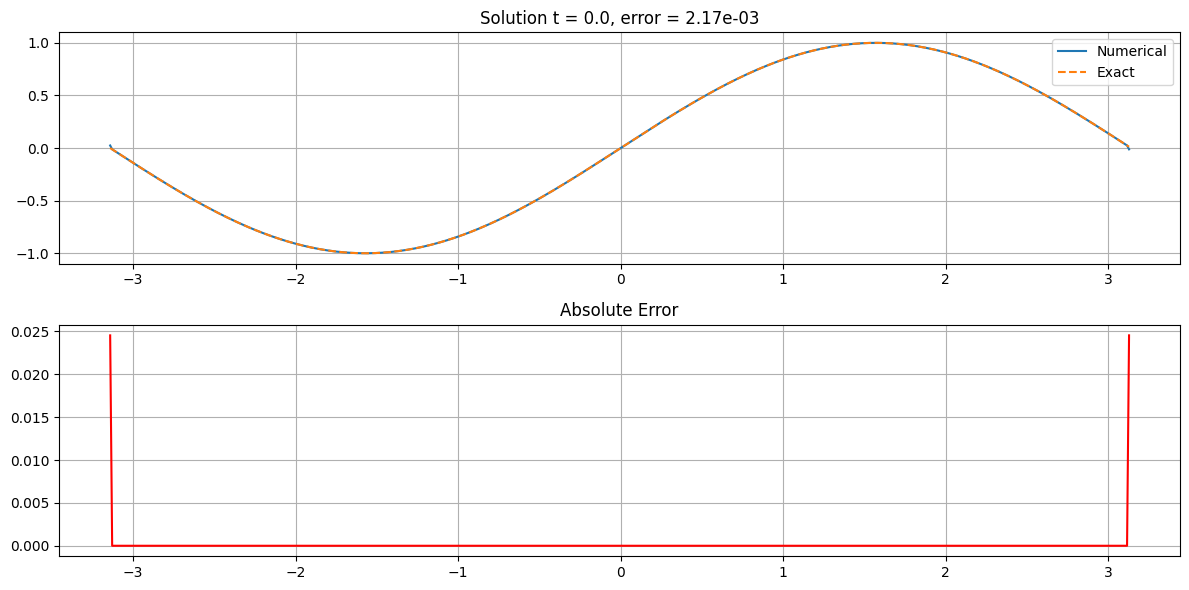

Closest available time to t_eval=0.5: 0.5
Test error t = 0.5: 1.155e+02


AssertionError: Error too large t = 0.5: 1.155e+02

In [8]:
# Define the symbols
t, x, xi = symbols('t x xi', real=True)
u_func = Function('u') 
u = u_func(t, x)

# Wave equation with psiOp
eq = Eq(diff(u, t, t), psiOp((-I*xi)**2, u))

# Create the solver
solver = PDESolver(eq)

Lt = 5.0

# Domain and initial conditions setup
solver.setup(
    Lx=2 * np.pi, Nx=512, Lt=Lt, Nt=1000,
    initial_condition=lambda x: np.sin(x),
    initial_velocity=lambda x: np.zeros_like(x)  # ∂u/∂t(x,0) = 0
)

# Solve
solver.solve()

# Plot energy
solver.plot_energy()
solver.plot_energy(log=True)

# Exact solution
def u_exact(x, t):
    return np.sin(x) * np.cos(t)

# Automatic testing
n_test = 10
test_set = [solver.test(u_exact=u_exact, t_eval=i * Lt / n_test, threshold=1, component='real') for i in range(n_test + 1)]


## Equation with psiOp depending on spatial potential


*********************************
* Partial differential equation *
*********************************

 2                                         
∂                    ⎛ 2                  ⎞
───(u(t, x)) = -psiOp⎝ξ  + cos(x), u(t, x)⎠
  2                                        
∂t                                         

********************
* Equation parsing *
********************


Equation rewritten in standard form: psiOp(xi**2 + cos(x), u(t, x)) + Derivative(u(t, x), (t, 2))
⚠️ psiOp detected: skipping expansion for safety

Expanded equation: psiOp(xi**2 + cos(x), u(t, x)) + Derivative(u(t, x), (t, 2))
Analyzing term: psiOp(xi**2 + cos(x), u(t, x))
  --> Classified as pseudo linear term (psiOp)
Analyzing term: Derivative(u(t, x), (t, 2))
  Derivative found: Derivative(u(t, x), (t, 2))
  --> Classified as linear
Final linear terms: {Derivative(u(t, x), (t, 2)): 1}
Final nonlinear terms: []
Symbol terms: []
Pseudo terms: [(1, xi**2 + cos(x))]
Source terms: []
⚠️  Pseudo‑different

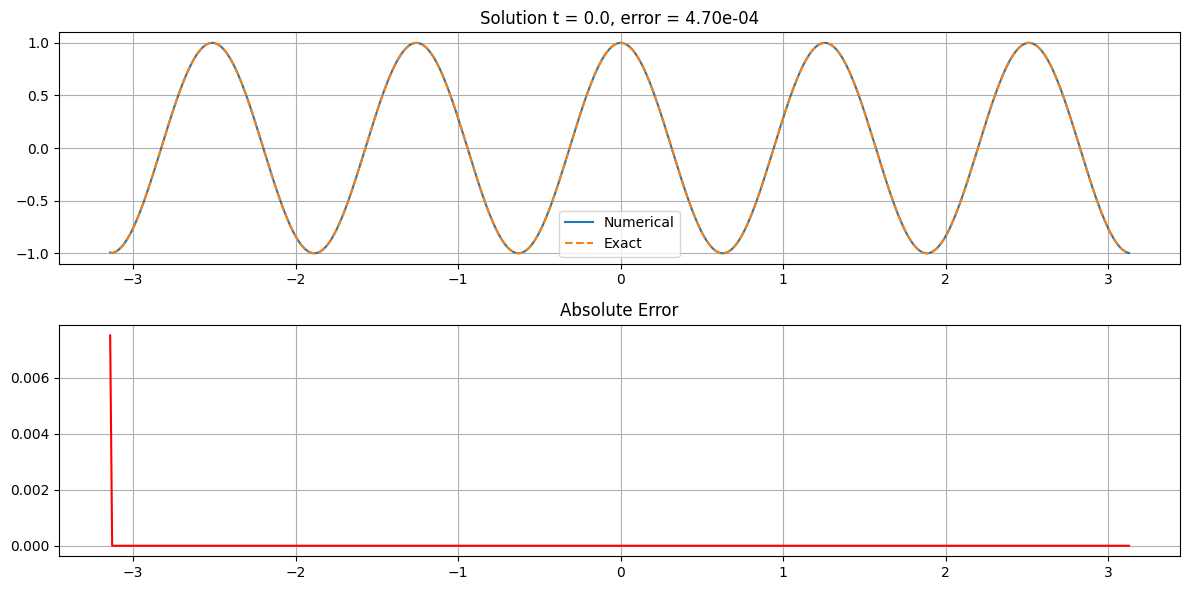

Closest available time to t_eval=0.5: 0.5
Test error t = 0.5: 1.033e-01


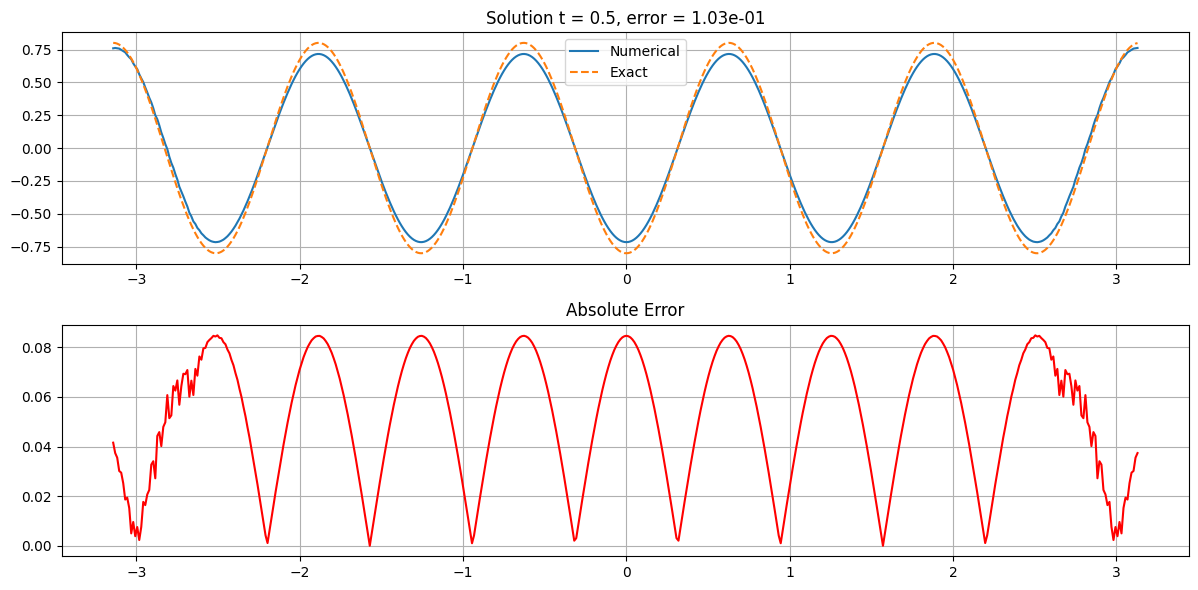

Closest available time to t_eval=1.0: 1.0
Test error t = 1.0: 6.627e-01


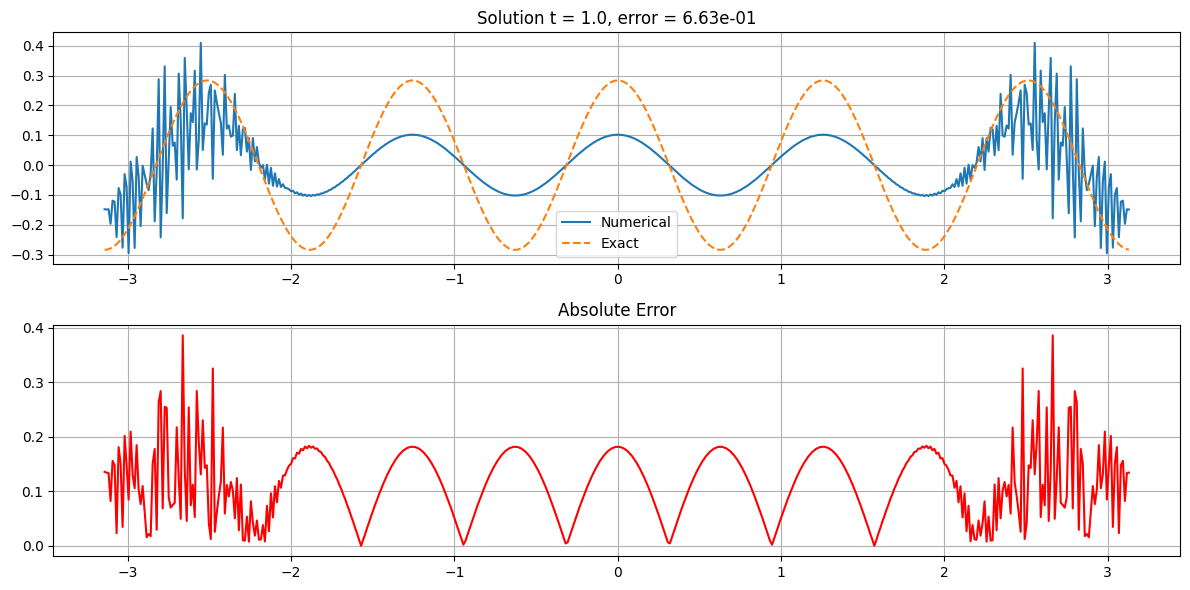

Closest available time to t_eval=1.5: 1.5
Test error t = 1.5: 1.501e+01


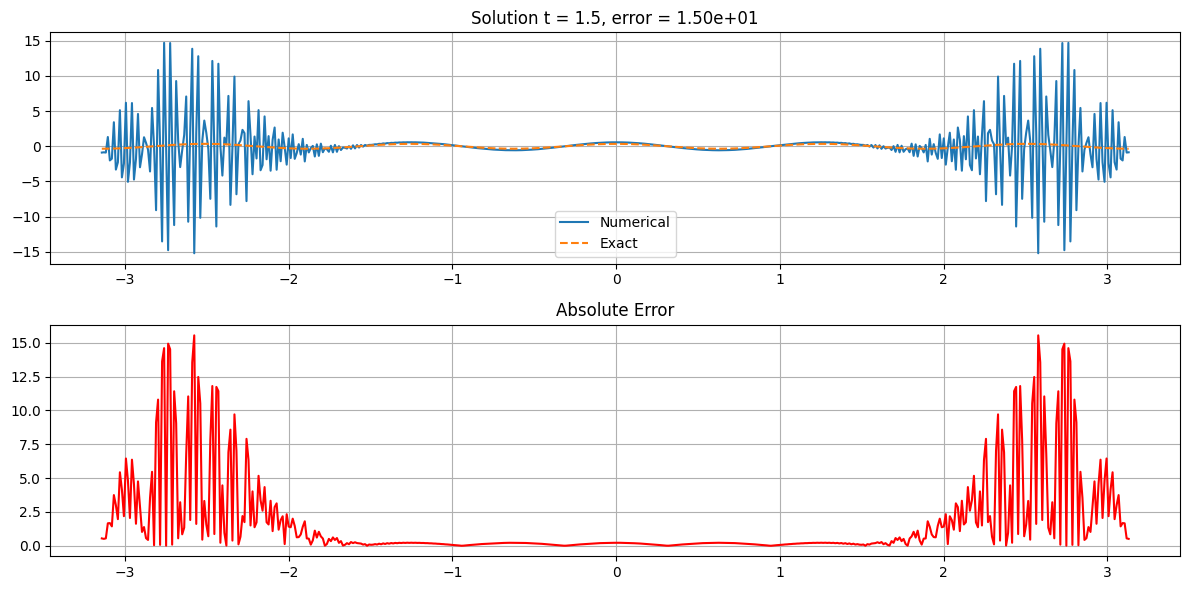

Closest available time to t_eval=2.0: 2.0
Test error t = 2.0: 4.076e+02


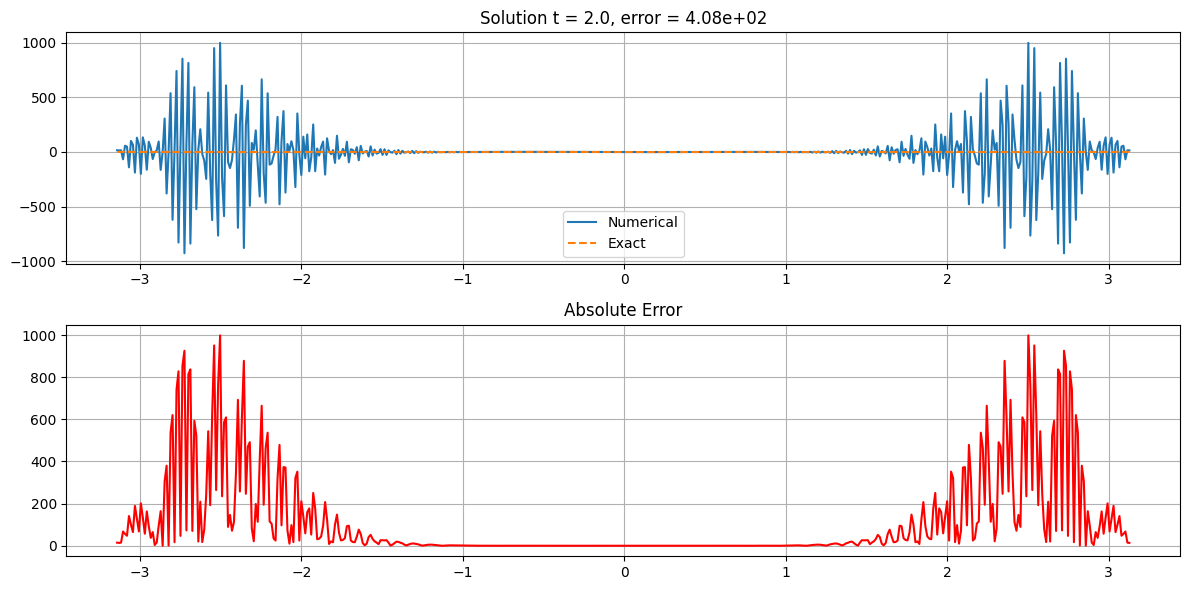

In [10]:
# Symbols
t, x, xi = symbols('t x xi', real=True)
u = Function('u')

# Symbol for the pseudo-differential operator (regular, x-dependent)
p_expr = xi**2 + cos(x)

# Define the PDE
equation = Eq(diff(u(t,x), t, t), -psiOp(p_expr, u(t,x)))
solver = PDESolver(equation)

# Setup the solver
Lx = 2 * np.pi
Nx = 512
Lt = 2.0
Nt = 1000
k = 5
omega = np.sqrt(k**2 + 0)  # approximation si V(x) ≈ 0

initial_condition = lambda x: np.cos(k * x)
initial_velocity = lambda x: 0 * x
# Exact solution
u_exact = lambda x, t: np.cos(omega * t) * np.cos(k * x)

solver.setup(
    Lx=Lx,
    Nx=Nx,
    Lt=Lt,
    Nt=Nt,
    boundary_condition='periodic',
    initial_condition=initial_condition,
    initial_velocity=initial_velocity
)

# Solve the PDE
solver.solve()

# Perform tests
for i in range(5):
    solver.test(u_exact=u_exact, t_eval=i * Lt / 4, threshold=3e5, component='real')


## Schrödinger equation
### With PDE

In [ ]:
# Define the symbols and the 1D Schrödinger equation
t, x, kx, xi, omega = symbols('t x kx xi omega')
u_func = Function('u') 
u = u_func(t, x)

eq = Eq(diff(u, t), -I * diff(u, x, x))

# Create the solver with ETD-RK4 time scheme
solver = PDESolver(eq, time_scheme='ETD-RK4', dealiasing_ratio=1/2)
Lt=2.0
# Configure the domain and initial condition: modulated Gaussian packet
solver.setup(
    Lx=20, Nx=1024, Lt=Lt, Nt=500,
    initial_condition=lambda x: np.exp(-x**2) * np.exp(1j * x)
)

# Solve
solver.solve()

# Exact solution (one of the two propagated packets, here moving to the left)
def u_exact(x, t):
    return 1 / np.sqrt(1 - 4j * t) * np.exp(1j * (x + t)) * np.exp(-((x + 2*t)**2) / (1 - 4j * t))

# Automatic testing
n_test = 4
test_set = [solver.test(u_exact=u_exact, t_eval=i * Lt / n_test, threshold=0.5, component='real') for i in range(n_test + 1)]

### With psiOp


*********************************
* Partial differential equation *
*********************************

∂                     ⎛  2         ⎞
──(u(t, x)) = -ⅈ⋅psiOp⎝-ξ , u(t, x)⎠
∂t                                  

********************
* Equation parsing *
********************


Equation rewritten in standard form: I*psiOp(-xi**2, u(t, x)) + Derivative(u(t, x), t)
⚠️ psiOp detected: skipping expansion for safety

Expanded equation: I*psiOp(-xi**2, u(t, x)) + Derivative(u(t, x), t)
Analyzing term: I*psiOp(-xi**2, u(t, x))
  --> Classified as pseudo linear term (psiOp)
Analyzing term: Derivative(u(t, x), t)
  Derivative found: Derivative(u(t, x), t)
  --> Classified as linear
Final linear terms: {Derivative(u(t, x), t): 1}
Final nonlinear terms: []
Symbol terms: []
Pseudo terms: [(I, -xi**2)]
Source terms: []
⚠️  Pseudo‑differential operator detected: all other linear terms have been rejected.

*******************************
* Linear operator computation *
*****************************

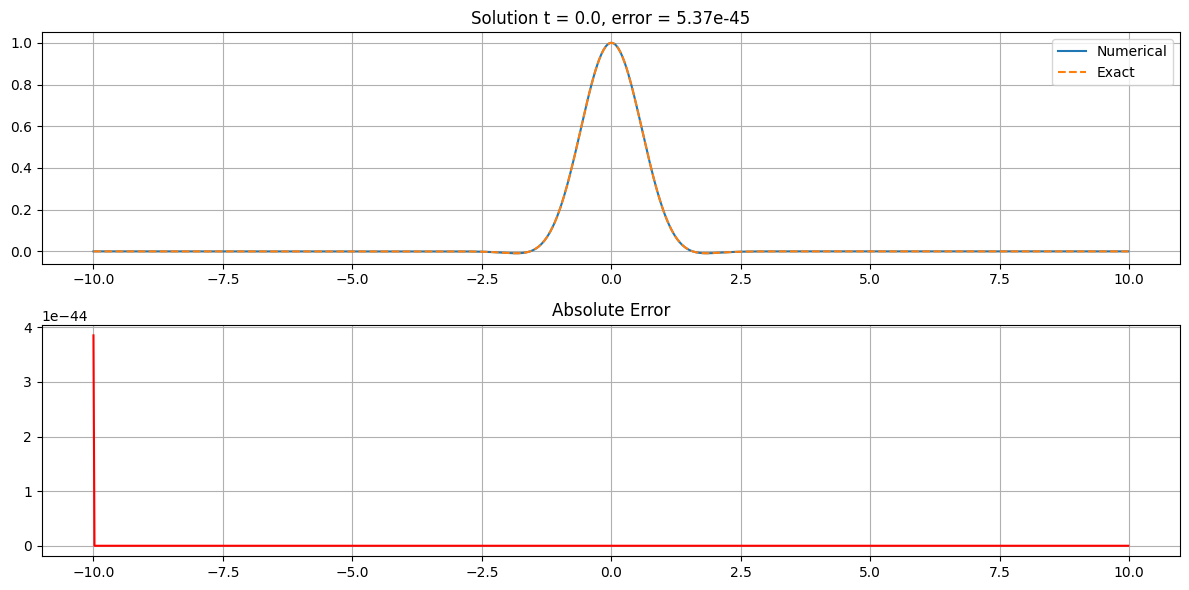

Closest available time to t_eval=0.5: 0.5
Test error t = 0.5: 4.410e-02


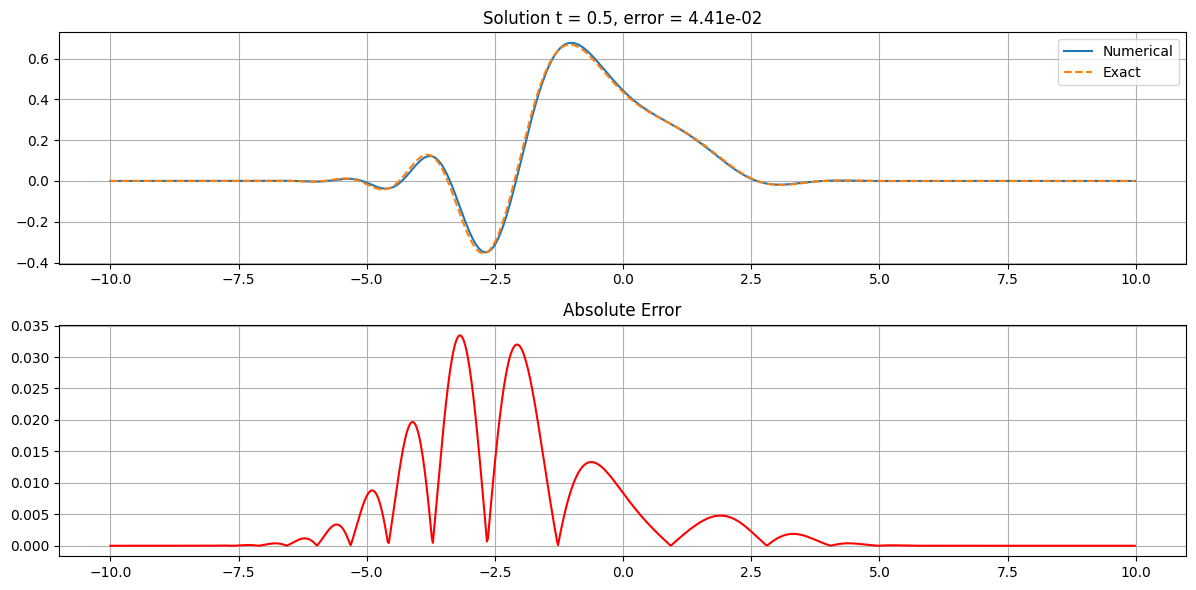

Closest available time to t_eval=1.0: 1.0
Test error t = 1.0: 4.589e-02


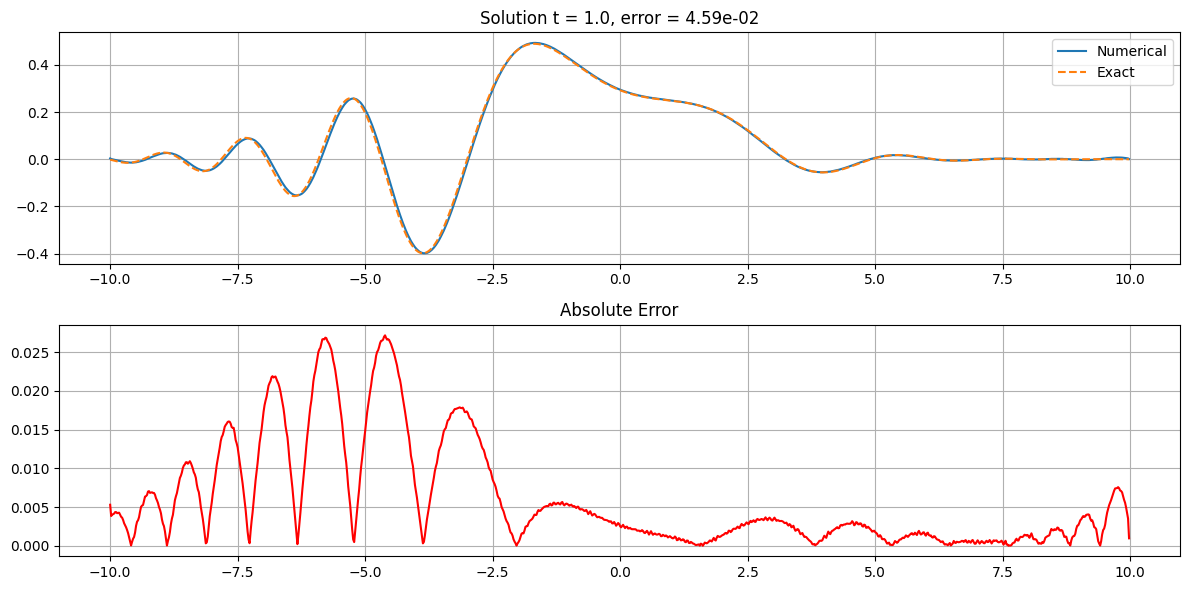

Closest available time to t_eval=1.5: 1.5
Test error t = 1.5: 9.680e-02


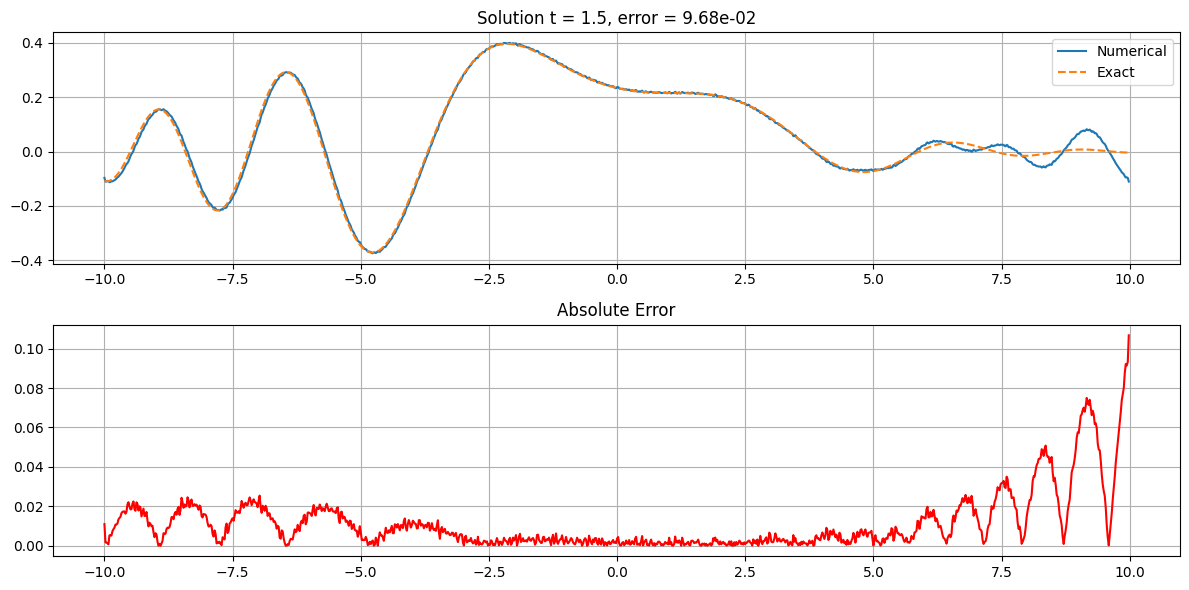

Closest available time to t_eval=2.0: 2.0
Test error t = 2.0: 2.597e-01


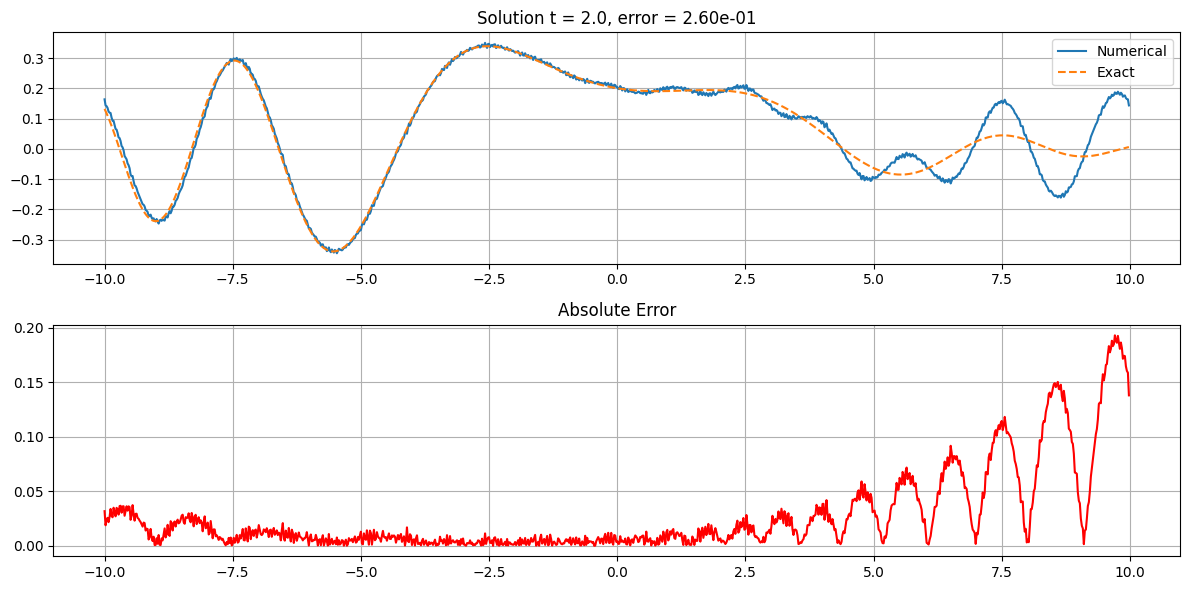

In [6]:
# Define the symbols and the 1D Schrödinger equation
t, x, kx, xi, omega = symbols('t x kx xi omega')
u_func = Function('u') 
u = u_func(t, x)

eq = Eq(diff(u, t), -I * psiOp(-xi**2, u))

# Create the solver with ETD-RK4 time scheme
solver = PDESolver(eq)
Lt=2.0
# Configure the domain and initial condition: modulated Gaussian packet
solver.setup(
    Lx=20, Nx=1024, Lt=Lt, Nt=500,
    initial_condition=lambda x: np.exp(-x**2) * np.exp(1j * x)
)

# Solve
solver.solve()

# Exact solution (one of the two propagated packets, here moving to the left)
def u_exact(x, t):
    return 1 / np.sqrt(1 - 4j * t) * np.exp(1j * (x + t)) * np.exp(-((x + 2*t)**2) / (1 - 4j * t))

# Automatic testing
n_test = 4
test_set = [solver.test(u_exact=u_exact, t_eval=i * Lt / n_test, threshold=0.5, component='real') for i in range(n_test + 1)]

## Klein-Gordon equation

In [ ]:
# Define the symbols and the Klein-Gordon equation
t, x, kx, xi, omega = symbols('t x kx xi omega')
u_func = Function('u') 
u = u_func(t, x)

eq = Eq(diff(u, t, t), diff(u, x, x) - u)

# Create the solver with ETD-RK4 scheme
solver = PDESolver(eq, time_scheme='ETD-RK4', dealiasing_ratio=1/4)
Lt=2.0
# Simulation parameters
solver.setup(
    Lx=20, Nx=1024, Lt=Lt, Nt=200,
    initial_condition=lambda x: np.cos(x),
    initial_velocity=lambda x: np.zeros_like(x)
)

# Solving
solver.solve()

solver.plot_energy()
solver.plot_energy(log=True) 

# Exact solution at t = 2: harmonic oscillation with frequency sqrt(2)
def u_exact(x, t):
    return np.cos(np.sqrt(2) * t) * np.cos(x)

# Automatic testing
n_test = 4
test_set = [solver.test(u_exact=u_exact, t_eval=i * Lt / n_test, threshold=5, component='real') for i in range(n_test + 1)]


## KdV equation

In [ ]:
# Define the symbols and the KdV equation
t, x, kx, xi, omega = symbols('t x kx xi omega')
u_func = Function('u') 
u = u_func(t, x)


eq = Eq(diff(u, t) + 6 * u * diff(u, x) - diff(u, x, x, x), 0)  # Standard KdV form

# Soliton parameters
c = 0.5   # Speed and amplitude of the soliton
x0 = 0.0  # Initial position

# Initial condition: centered soliton
initial_condition = lambda x: c / 2 * (1 / np.cosh(np.sqrt(c)/2 * (x - x0)))**2

# Create the solver with periodic boundary conditions and adapted dealiasing
solver = PDESolver(eq, time_scheme='ETD-RK4', dealiasing_ratio=2/3)

# Simulation parameters
Lx = 40
Nx = 2048
Lt = 5.0
Nt = 1000

# Setup
solver.setup(Lx=Lx, Nx=Nx, Lt=Lt, Nt=Nt, initial_condition=initial_condition)

# Solve
solver.solve()

# Exact solution at t = Lt
def u_exact(x, t):
    return c / 2 * (1 / np.cosh(np.sqrt(c)/2 * (x - c*t - x0)))**2

# Automatic testing
n_test = 6
test_set = [solver.test(u_exact=u_exact, t_eval=i * Lt / n_test, threshold=0.5, component='real') for i in range(n_test + 1)]


## Biharmonic equation

In [ ]:
# Definition of the 1D biharmonic equation
t, x, kx, xi, omega = symbols('t x kx xi omega')
u_func = Function('u') 
u = u_func(t, x)

biharmonic_eq = Eq(diff(u, t), -diff(u, x, x, x, x))

# Creation of the solver with periodic boundary conditions
solver = PDESolver(biharmonic_eq)

# Configuration of the domain and initial condition
Lx = 2 * np.pi
Nx = 256
Lt = 1.0
Nt = 200

solver.setup(
    Lx=Lx, Nx=Nx,
    Lt=Lt, Nt=Nt,
    initial_condition=lambda x: np.sin(x)
)

# Solving
solver.solve()

# Exact solution
def u_exact(x, t):
    return np.sin(x) * np.exp(-t)

# Automatic testing
n_test = 4
test_set = [solver.test(u_exact=u_exact, t_eval=i * Lt / n_test, threshold=5e-2, component='real') for i in range(n_test + 1)]